In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

import sys
sys.path.append("..//neural/")
import format_waveform_data, waveform_analysis
sys.path.append("..//utils/")
from load_matlab_data import loadmat_sbx

import scipy.io
from scipy.io import loadmat
import os

In [102]:
''' set paths '''
bird_id = 'RBY94'
session_id = '241129'
locker_root = f"Z:/Isabel/data/hpc_implants/{bird_id}/{bird_id}_{session_id}/"

# to load waveforms and probe info
ephys_id = "RBY94_241129_112536"
ks_dir = "kilosort4_blanked/"
session_dir = f"{locker_root}/{ephys_id}/" # locker
ephys_dir = f"{session_dir}raw_ephys_output/"

# specify broken channels for this session
# broken_channels = np.asarray([3, 23, 28, 29, 41, 48, 50, 61, 63]) # AMB154_241119
broken_channels = np.asarray([14, 22, 35, 42, 48]) # RBY94_241129

# to load raw keypoints, model performance measures, behavior
# pred_file = '250219_posture_2stage_face.npy' # AMB154
pred_file = '250118_posture_2stage_face.npy' # RBY94
pred_path = f"{locker_root}{pred_file}"
data_dir = f"{locker_root}behavior_data/"
annotated_seed_file = "annotatedSeeds.mat"

# to load the arena objects
arena_dir = 'C:/Users/ilow1/Documents/code/il_rig_control/arena_alignment/'
arena_items_file = 'arena_items_2.mat'

In [6]:
# set save folder
save_plots = False
save_dir = f"../figures/basic_neural_analysis/{bird_id}/"
if os.path.isdir(save_dir):
    print('save directory exists')
else:
    os.mkdir(save_dir)
save_folder = f"{save_dir}/{bird_id}_{session_id}/"
if os.path.isdir(save_folder):
    print('save folder exists')
else:
    os.mkdir(save_folder)

save directory exists
save folder exists


In [30]:
''' probe info '''
sampling_rate = 30000
n_channels_shank = 32
A_shank = np.arange(n_channels_shank)
B_shank = np.arange(n_channels_shank) + n_channels_shank
A_shank = np.setdiff1d(A_shank, broken_channels)
B_shank = np.setdiff1d(B_shank, broken_channels)

In [14]:
''' load and format the waveform struct '''
waveform_struct = format_waveform_data.load_wf_data(session_dir, ks_dir=ks_dir)
wf_ids = waveform_struct['goodIDs']
mean_waveforms, wf_channels, _, ch_names = format_waveform_data.sort_wf_by_channel('', waveform_struct,
                                                                                   data_dir=ephys_dir,
                                                                                   return_ch_names=True)

Z:/Isabel/data/hpc_implants/RBY94/RBY94_241129//RBY94_241129_112536/kilosort4_blanked/waveformStruct.mat
dict_keys(['mxWF', 'max_site', 'pcWF', 'meanRate', 'waveFormsMean', 'spkDur', 'spkOffset', 'goodIDs', 'goodLabels', 'medISI', 'contam', 'nSpikes'])
Z:/Isabel/data/hpc_implants/RBY94/RBY94_241129//RBY94_241129_112536/raw_ephys_output/intan_info.mat


In [15]:
# filter out the bad channels and get the new channel index
all_ch = np.arange(mean_waveforms.shape[1])
good_idx = np.setdiff1d(all_ch, broken_channels)
mean_waveforms = mean_waveforms[:, good_idx]
ch_names = [ch_names[i] for i in good_idx]
wf_ch_idx = np.asarray([ch_names.index(ch) for ch in wf_channels])
n_cells = mean_waveforms.shape[0]

# get the cell IDs and raw spike times
good_clusters, spike_id, spike_samp_raw = format_waveform_data.get_spike_times(session_dir, ks_dir=ks_dir)
assert good_clusters.shape[0] == n_cells

In [10]:
''' load the arena interactions '''
seed_struct = loadmat_sbx(f'{data_dir}{annotated_seed_file}')['annotatedSeeds']
count_data = seed_struct['countData']
print('\n')
print(seed_struct.keys())
print('\n')
print(count_data.keys())

Z:/Isabel/data/hpc_implants/RBY94/RBY94_241129/behavior_data/annotatedSeeds.mat
dict_keys(['countData', 'bk_height_seedDetect', 'smSeedWindow', 'gainThresh', 'loseThresh', 'minLoseDur', 'validFrames', 'seedIntTol', 'path', 'beakPos', 'smSeed', 'cacheLoc', 'seedTimes', 'nEvents', 'newCacheTimes', 'endCacheTimes', 'cacheNum', 'fromCache_site', 'fromCache_event', 'toCache_site', 'toCache_event', 'gainMat', 'loseMat', 'initImgs', 'preIms', 'postIms', 'flagInt', 'seedChanges', 'initSeedCounts', 'prePreds', 'postPreds'])


dict_keys(['newPerch', 'endPerch', 'perchNum', 'newSite', 'endSite', 'siteNum', 'newFeeder', 'endFeeder', 'feederNum', 'newWater', 'endWater', 'waterNum', 'newBeakPerch', 'endBeakPerch', 'beakPerchNum', 'params'])


In [108]:
''' load the arena objects '''
arena_data = loadmat(f'{arena_dir}{arena_items_file}', squeeze_me=True)
arena_data["perches"] = arena_data["perch_w_site"]
arena_data["feeder_perches"] = arena_data["perch_no_site"]

n_sites = arena_data["perches"].shape[0]
n_feeders = arena_data["feeder_perches"].shape[0]

In [163]:
# get the centroid for each site
site_centers = np.zeros((n_sites, 2))
for site in range(n_sites):
    site_centers[site] = arena_data["perches"][site]['Centroid']

# for each cache site perch, get its Euclidean distance to all other cache site perches
site_dist = np.zeros((n_sites, n_sites-1))
for site in range(n_sites):
    not_site = np.setdiff1d(np.arange(n_sites), site)
    center = site_centers[site]
    site_dist[site] = np.sqrt(np.sum((site_centers[site] - site_centers[not_site])**2, axis=1))

# bin the distances into 10 bins
cts, vals = np.histogram(site_dist, bins=10)
site_dist_binned = np.digitize(site_dist, bins=vals)

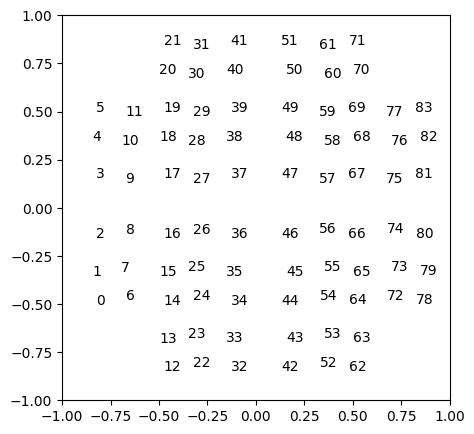

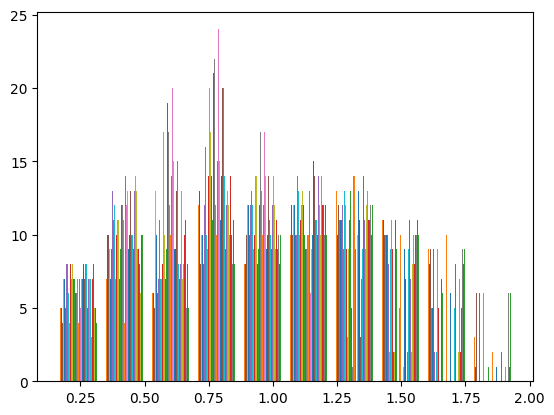

In [166]:
# plot the site locations
f, ax = plt.subplots(1, 1, figsize=(5, 5))
for i, center in enumerate(site_centers):
    ax.text(center[0], center[1], f'{i}')
ax.set_ylim(-1, 1)
ax.set_xlim(-1, 1)
plt.show()

# histogram of distances
plt.hist(site_dist)
plt.show()

In [28]:
''' load the frame times '''
framet_raw = np.load(f'{data_dir}frame_times.npy')
framet_raw = np.squeeze(framet_raw)
dt = np.unique(np.round(np.diff(framet_raw), 4))
if dt.shape[0] > 1:
    print(f'warning irregular frame times!\nframe dt = {dt}')
else:
    dt = dt[0]
    
assert seed_struct['validFrames'].shape[0] == framet_raw.shape[0]

In [31]:
# align so that 0 is the video start time
start_t = framet_raw[0]
frame_t = framet_raw - start_t
spike_t = spike_samp_raw - start_t*sampling_rate
frame_samples = np.append(frame_t, frame_t[-1] + dt)*sampling_rate

# keep only spikes from within the session
spike_id = spike_id[(spike_t >= 0) & (spike_t <= frame_samples[-1])]
spike_t = spike_t[(spike_t >= 0) & (spike_t <= frame_samples[-1])]

n_frames = frame_t.shape[0]

In [49]:
''' spikes per frame and spike bool '''
spike_ct_frame = np.zeros((n_cells, n_frames))
i = -1
for c_idx, cell in enumerate(good_clusters):
    i += 1
    spk_times = spike_t[spike_id==cell]       
    spike_ct_frame[i], _ = np.histogram(spk_times, frame_samples)
spike_bool = spike_ct_frame.astype(bool)

In [69]:
''' z-scored firing rates '''
# instantaneous firing rate per frame
fr_frame = spike_ct_frame / dt

# average firing rate across the whole session
avg_fr = np.mean(fr_frame, axis=1)

# regularized standard deviation
std_fr = stats.tstd(fr_frame, axis=1) + 0.6

# zscore and transpose to frames x cells
fr_zscore = (fr_frame.T - avg_fr) / std_fr

Population Vector Correlation Analysis
--------------------
Criteria paraphrased from *Chettih et al. 2025 (bioRxiv)*.
#### Behavior classification
**Visits** are perch arrivals with no subsequent interaction of any kind. Visit windows are ±500 ms from perch arrival, further refined to exclude confounding events (begin after the offset of any interactions pre-visit to this site and end early if the bird leaves the perch). Neural data is averaged within this window.

**Caches and retrievals** are cache site interactions where a seed is added or removed. Site interaction windows start 250 ms before interaction onset and 250 ms after interaction offset (adjusting to 240ms or 12 frames at 50Hz). Further refined to start at departure from the previous perch and end at arrival to the next perch. For long site interactions (>2 s), the window includes only time periods up to 1 s after onset and up to 1 s before offset, excluding the times between. Neural data is averaged within this window.

#### Neural processing + analysis
- z score firing rates or subtract off baseline average rate and divide by standard deviation regularized by adding a small number (0.6 Hz).
- Subtract off the mean across all instances of the action (e.g., all visits).
- Exclude pairs separated by less than 1 min.
- Normalize by multiplying by a constant so that visit-visit correlation = 1.

In [25]:
''' classify caches/retrievals '''
# data params
all_int_start = count_data['newSite']
all_int_end = count_data['endSite']
all_int_changes = np.sum(seed_struct['seedChanges'], axis=1)
n_interactions = all_int_start.shape[0]

# caches = add a seed
cache_onsets = all_int_start[all_int_changes > 0]
cache_offsets = all_int_end[all_int_changes > 0]
n_cache = cache_offsets.shape[0]

# retrievals = subtract a seed
retrieval_onsets = all_int_start[all_int_changes < 0]
retrieval_offsets = all_int_end[all_int_changes < 0]

46 total caches


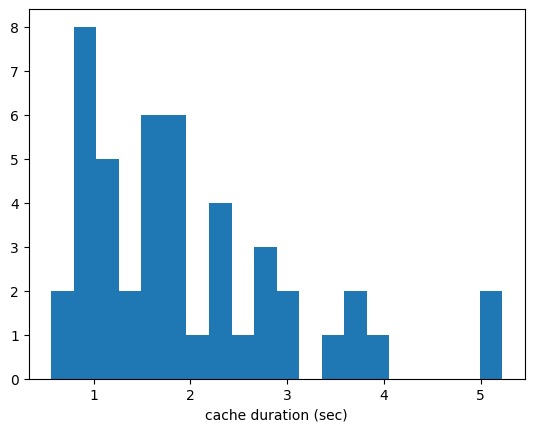

In [26]:
# plot cache durations
print(f'{n_cache} total caches')
cache_dur = cache_offsets - cache_onsets
plt.hist(cache_dur/50, bins=20)
plt.xlabel('cache duration (sec)')
plt.show()

In [77]:
''' define the window for cache vector analysis '''
cache_window = 12 # frames or 240 ms

# get all perch interactions
all_perch_start = count_data['newPerch']
all_perch_end = count_data['endPerch']
all_perch_idx = count_data['perchNum']
n_perches = all_perch_start.shape[0]

# identify perches with a cache interaction
cache_idx = np.zeros(n_perches).astype(bool)
for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
    start_idx = cache_onsets > ps
    end_idx = cache_onsets < pe
    if any(start_idx & end_idx):
        cache_idx[i] = True
assert np.sum(cache_idx) == n_cache

# get the cache window
cache_idx_onsets = np.zeros(n_cache, dtype=int)
cache_idx_offsets = np.zeros(n_cache, dtype=int)
j = -1
for i in range(n_perches):
    if cache_idx[i]:
        j += 1
        this_start = cache_onsets[j] - cache_window
        this_end = cache_offsets[j] + cache_window
        if i > 0:
            last_end = all_perch_end[i-1]
        else:
            last_end = 0
        if i < n_perches - 1:
            next_start = all_perch_start[i+1]
        else:
            next_start = n_frames - 1
        cache_idx_onsets[j] = np.max([this_start, last_end]).astype(int)
        cache_idx_offsets[j] = np.min([this_end, next_start]).astype(int)

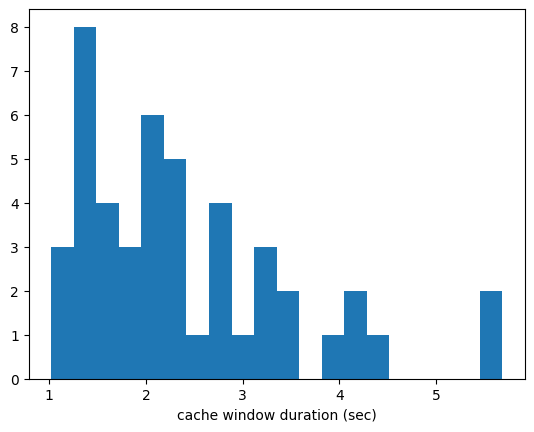

In [45]:
# plot cache window durations
plt.hist((cache_idx_offsets - cache_idx_onsets)/50, bins=20)
plt.xlabel('cache window duration (sec)')
plt.show()

In [46]:
''' get indices for food and water interactions '''
# eating times
eat_onsets = count_data['newBeakPerch']
eat_offsets = count_data['endBeakPerch']

# feeder interactions
feed_onsets = count_data['newFeeder']
feed_offsets = count_data['endFeeder']

# water interactions
drink_onsets = count_data['newWater']
drink_offsets = count_data['endWater']

In [75]:
''' classify visits '''
visit_window = 25 # frames or 500 ms

# exclude perches with eating and site interactions
all_non_visit_start = np.concatenate([eat_onsets, feed_onsets, drink_onsets, all_int_start])
visit_idx = np.full(n_perches, 1).astype(bool)
for i, (ps, pe) in enumerate(zip(all_perch_start, all_perch_end)):
    start_idx = all_non_visit_start > ps
    end_idx = all_non_visit_start < pe
    if any(start_idx & end_idx):
        visit_idx[i] = False
n_visits = np.sum(visit_idx)

# get the visit window
visit_onsets = np.zeros(n_visits, dtype=int)
visit_offsets = np.zeros(n_visits, dtype=int)
j = -1
for i in range(n_perches):
    if visit_idx[i]:
        j += 1
        this_start = all_perch_start[i]
        this_end = all_perch_end[i]
        if i > 0:
            last_end = all_perch_end[i-1]
        else:
            last_end = 0
        visit_onsets[j] = np.max([this_start - visit_window, last_end]).astype(int)
        visit_offsets[j] = np.min([this_start + visit_window, this_end]).astype(int)

1193 total visits


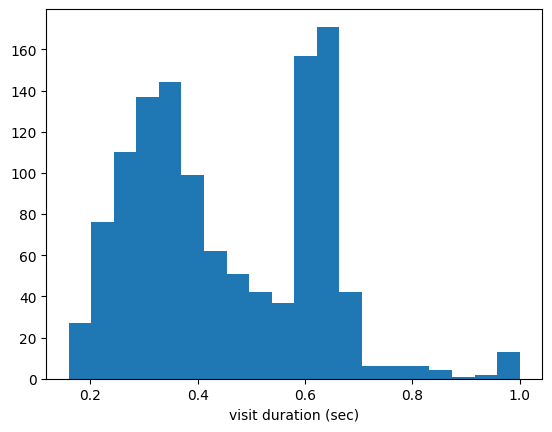

In [48]:
# plot visit durations
print(f'{n_visits} total visits')
visit_dur = visit_offsets - visit_onsets
plt.hist(visit_dur/50, bins=20)
plt.xlabel('visit duration (sec)')
plt.show()

In [96]:
''' get z-scored firing rate by visit/cache '''
# by visit
visit_fr = np.zeros((n_visits, n_cells))
for i, (v_start_idx, v_end_idx) in enumerate(zip(visit_onsets, visit_offsets)):
    visit_fr[i] = np.mean(fr_zscore[v_start_idx:v_end_idx], axis=0)

# by cache
cache_fr = np.zeros((n_cache, n_cells))
for i, (c_start_idx, c_end_idx) in enumerate(zip(cache_idx_onsets, cache_idx_offsets)):
    cache_fr[i] = np.mean(fr_zscore[c_start_idx:c_end_idx], axis=0)

# subtract off the means
visit_fr = visit_fr - np.mean(visit_fr, axis=0)
cache_fr = cache_fr - np.mean(cache_fr, axis=0)

In [277]:
visit_fr.shape # visit_events x cells

(1193, 101)

In [279]:
site_idx_visits # visit_events vector

array([64, 11, 10, ..., 29, 39, 75], dtype=uint8)

In [280]:
site_dist_binned.shape # n_perches x n_perches - 1

(84, 83)

In [269]:
''' visit-visit population vector correlations '''
# get the site index for each perch event
site_idx_all = count_data['perchNum']
site_idx_visits = site_idx_all[visit_idx]

# collect the vectors by site
site_visit_fr = []
for site in range(n_sites):
    site_visit_fr.append(visit_fr[site_idx_visits == site])

# get the pairwise correlations by distance
all_visit_correlations = [np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), 
                   np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([])]
for site in range(n_sites):
    # same to same
    this_site_fr = site_visit_fr[site]
    this_site_corr = np.abs(dist.pdist(this_site_fr, 'correlation') - 1)
    all_visit_correlations[0] = np.append(all_visit_correlations[0], this_site_corr)

    # across sites
    dist_idx = site_dist_binned[site]
    for d in np.arange(10)+1:
        site_idx = np.where(dist_idx == d)[0] + 1
        for i, s in enumerate(site_idx):
            if i == 0:
                those_sites_fr = site_visit_fr[s]
            else:
                those_sites_fr = np.vstack((those_sites_fr, site_visit_fr[s]))
        cross_site_corr = np.abs(dist.cdist(this_site_fr, those_sites_fr, 'correlation') - 1)
        all_visit_correlations[d] = np.append(all_visit_correlations[d], np.ravel(cross_site_corr))

for i in range(len(all_visit_correlations)):
    all_visit_correlations[i] = np.asarray(all_visit_correlations[i])

In [270]:
# normalize s.t. same site correlation is 1
norm_factor = 1/np.mean(all_visit_correlations[0])
for i in range(len(all_visit_correlations)):
    all_visit_correlations[i] = all_visit_correlations[i] * norm_factor

In [271]:
# data params for plotting
avg_correlations = np.zeros(len(all_visit_correlations))
sem_correlations = np.zeros(len(all_visit_correlations))
for i in range(len(all_correlations)):
    avg_correlations[i] = np.mean(all_visit_correlations[i])
    sem_correlations[i] = stats.sem(all_visit_correlations[i])

rough_distances_cm = np.zeros(11)
for d in np.arange(10)+1:
    rough_distances_cm[d] = np.mean(site_dist[site_dist_binned==d]) * 13 * 2.54

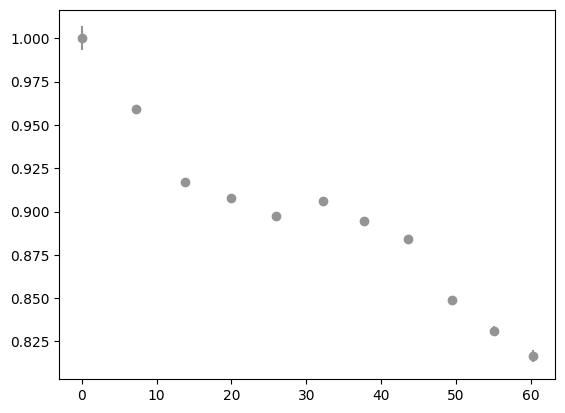

In [272]:
plt.scatter(rough_distances_cm, avg_correlations, c='xkcd:gray')
plt.vlines(rough_distances_cm, avg_correlations-sem_correlations, avg_correlations+sem_correlations, colors='xkcd:gray')
plt.show()

In [273]:
''' cache-cache population vector correlations '''
# get the site index for each cache event
site_idx_all = count_data['perchNum']
site_idx_caches = site_idx_all[cache_idx]

# collect the vectors by site
site_cache_fr = []
for site in range(n_sites):
    site_cache_fr.append(cache_fr[site_idx_caches == site])

# get the pairwise correlations by distance
all_cache_correlations = [np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), 
                   np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([]), np.asarray([])]
for site in range(n_sites):
    # same to same
    this_site_fr = site_cache_fr[site]
    this_site_corr = np.abs(dist.pdist(this_site_fr, 'correlation') - 1)
    all_cache_correlations[0] = np.append(all_cache_correlations[0], this_site_corr)

    # across sites
    dist_idx = site_dist_binned[site]
    for d in np.arange(10)+1:
        site_idx = np.where(dist_idx == d)[0] + 1
        for i, s in enumerate(site_idx):
            if i == 0:
                those_sites_fr = site_cache_fr[s]
            else:
                those_sites_fr = np.vstack((those_sites_fr, site_cache_fr[s]))
        cross_site_corr = np.abs(dist.cdist(this_site_fr, those_sites_fr, 'correlation') - 1)
        all_cache_correlations[d] = np.append(all_cache_correlations[d], np.ravel(cross_site_corr))

# normalize to visit-visit
for i in range(len(all_cache_correlations)):
    all_cache_correlations[i] = np.asarray(all_cache_correlations[i]) * norm_factor

In [274]:
# data params for plotting
avg_correlations = np.zeros(len(all_cache_correlations))
sem_correlations = np.zeros(len(all_cache_correlations))
for i in range(len(all_correlations)):
    avg_correlations[i] = np.mean(all_cache_correlations[i])
    sem_correlations[i] = stats.sem(all_cache_correlations[i])

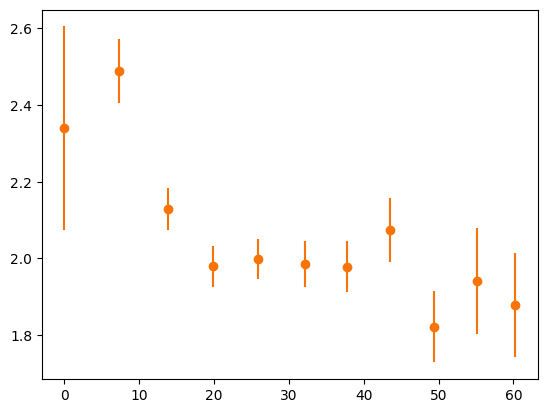

In [275]:
plt.scatter(rough_distances_cm, avg_correlations, c='xkcd:orange')
plt.vlines(rough_distances_cm, avg_correlations-sem_correlations, avg_correlations+sem_correlations, colors='xkcd:orange')
plt.show()

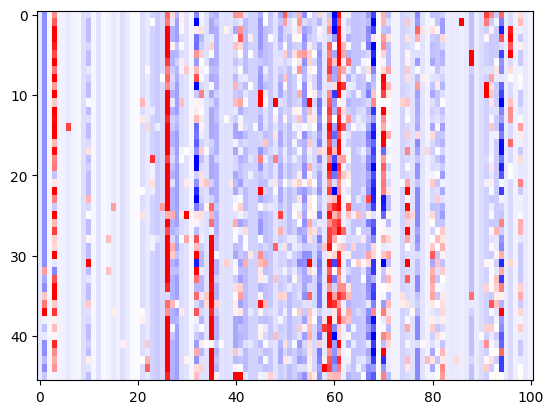

In [97]:
plt.imshow(cache_fr, aspect='auto', cmap='bwr',
           clim=[-0.5, 0.5], interpolation='none')

In [100]:
np.min(cache_fr)

np.float64(-0.763946341080837)